## Synthetic Control

In [ ]:
%pip install -r "requirements.txt"

# import necessary libraries and functions
import datetime as dt
from did_functions import *
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow
from sdid import SyntheticDiffInDiff

Hardcoded values for analysis

In [18]:
time_col = 'year_month'
grouping_col = 'Agency'
output_name = 'crashes'
initial_date = '2014-04-01'
city_of_interest = 'San Francisco'

### Load Data

In [19]:
collisions_ca_path = r"../data/clean_data/California_Collisions_Clean.csv"
collisions_ca = load_data(collisions_ca_path)

California_Collisions_Clean.csv converted to dataframe.


## Process Data before Modeling

In [20]:
# aggregate data 
monthly_did_data = aggregate_df(collisions_ca, cols = [time_col, grouping_col], output = output_name)
monthly_did_data[time_col] = pd.to_datetime(monthly_did_data[time_col]).astype('period[M]').dt.to_timestamp()

# drop nas
monthly_did_data = monthly_did_data[monthly_did_data['Agency'].notna()]

In [21]:
TREATMENT_DATE = pd.Timestamp(initial_date)  #Closest date after March 18th, 2014
TREATED_CITY   = city_of_interest

monthly_did_data['post'] = (monthly_did_data[time_col] >= TREATMENT_DATE).astype(int)
monthly_did_data['treat'] = (monthly_did_data['Agency'] == TREATED_CITY).astype(int)

###  Find Control Cities

In [22]:
control_cities = monthly_did_data['Agency'].unique

### Convert Year Month Variable to a numeric counter

In [23]:
# Convert time formats to get months since first date
monthly_did_data['time_numeric'] = (
    (monthly_did_data[time_col].dt.year - monthly_did_data[time_col].dt.year.min()) * 12 +
    (monthly_did_data[time_col].dt.month - monthly_did_data[time_col].dt.month.min())
)

min_year = monthly_did_data[time_col].dt.year.min()
min_month = monthly_did_data[time_col].dt.month.min()
treatment_numeric = (2014 - min_year) * 12 + (3 - min_month)

## Create Model

In [ ]:
model = SyntheticDiffInDiff(
    data        = monthly_did_data,
    outcome_col = 'crashes',
    times_col   = 'time_numeric',
    units_col   = 'Agency',
    treat_col   = 'treat',
    post_col    = 'post',
)

result = model.fit()

In [ ]:
# Synthetic control vs actual SF trends
model.plot_synthetic_control()

# Raw trends for all cities
model.plot_raw_trends()

# print the full summary
model.summary()

model.plot_synthetic_control()

INFO:sdid.core:Creating raw trends plot...


Figure(1000x600)


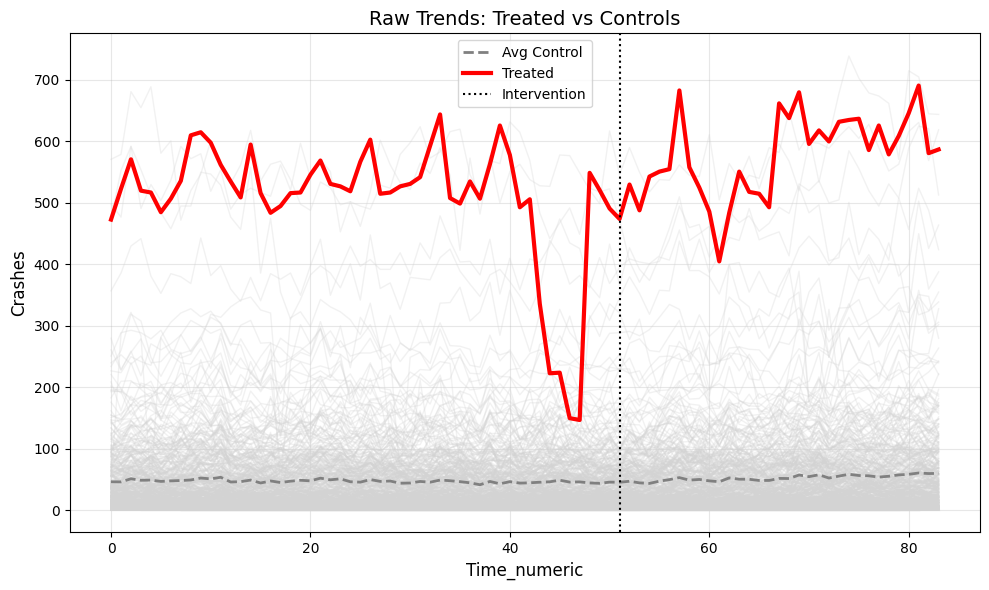

In [26]:
result = model.plot_raw_trends()
print((result))

In [ ]:
result2 = model.plot_synthetic_control()

for ax in result2.axes:
    ax.set_ylabel("Crashes")
    ax.set_xlabel("Months since January 2010")

result2

In [28]:
model.estimate_se(n_bootstrap=200, n_jobs=4)
print(model.summary(confidence_level = .95))

INFO:sdid.core:Estimating standard error with 200 bootstrap samples...
INFO:sdid.core:Data validated: 2 treated units, 434 controls, 51 pre-periods, 33 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Data validated: 2 treated units, 434 controls, 51 pre-periods, 33 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Data validated: 2 treated units, 434 controls, 51 pre-periods, 33 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Data validated: 2 treated units, 434 controls, 51 pre-periods, 33 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Unit regularization: 40.1893
INFO:sdid.core:Unit regularization: 40.0482
INFO:sdid.core:Unit regularization: 40.1881
INFO:sdid.core:Unit regularization: 40.1819
INFO:sdid.core:Data validated: 2 treated unit

Model not yet fitted. Call fit() first.


In [ ]:
model.get_weights_summary()